# QMI2D: amplitude no plano de Dalitz e ajuste de um toy

Este exemplo constrói um campo complexo bidimensional, compara interpolações e faz
um pequeno teste de recuperação de magnitude e fase com dados simulados de
$B^+\to K^-K^+K^+$. O modelo é didático, sem pretensão de reproduzir uma análise publicada.

Execute as células em ordem em um kernel novo com o pacote instalado conforme
[TUTORIALS.md](TUTORIALS.md). Não são necessários arquivos externos nem GPU.
Massas estão em GeV, invariantes em GeV² e fases em radianos.

Ao contrário do QMI 1D, usado como `lineshape` de uma `Resonance`, o `QMI2D`
é conectado ao modelo por `DalitzAmplitude`: ele já descreve a dependência conjunta
em $s_{12}$ e $s_{13}$, sem fatores angulares ou barreiras de um isóbaro.

In [1]:
from dalitzplotfitter import enable_x64

enable_x64()

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DalitzAmplitude, DecayChannel, DecayModel, FitSession, NonResonant,
    Parameter, QMI2D, RealImag, generate_toy, physical_bin_mask,
)

SEED = 20260913
N_EVENTS = 4000
NORMALIZATION_RESOLUTION = 80
INVERSE_RESOLUTION = 320

## 1. Binning físico e simetria das partículas idênticas

A ordem das filhas é `("K-", "K+", "K+")`: trocar as filhas de índices 1 e 2
troca $s_{12}$ por $s_{13}$. Assim, `folded=True` impõe a simetria avaliando o campo
em $s_\mathrm{low}=\min(s_{12},s_{13})$ e $s_\mathrm{high}=\max(s_{12},s_{13})$.
Os dois eixos precisam ter as mesmas bordas. Essa escolha depende da identidade
física das partículas, não apenas de massas iguais.

As bordas vêm dos limites cinemáticos exatos. `physical_bin_mask` procura
interseções com a fronteira física por amostragem; aumentamos a resolução da
busca para verificar a estabilidade desta malha. Uma célula ativa pode estar
apenas parcialmente dentro da região física.

In [2]:
channel = DecayChannel("B+", ("K-", "K+", "K+"))
m1, m2, m3 = channel.daughter_masses
smin = (m1 + m2) ** 2
smax = (channel.parent_mass - m3) ** 2
edges = tuple(np.linspace(smin, smax, 5))  # 4 x 4 células
centers = 0.5 * (np.asarray(edges[:-1]) + np.asarray(edges[1:]))

mask_options = dict(
    mother_mass=channel.parent_mass, masses=channel.daughter_masses,
    folded=True,
)
mask = physical_bin_mask(edges, edges, samples_per_bin=257, **mask_options)
mask_finer = physical_bin_mask(edges, edges, samples_per_bin=1025, **mask_options)
assert mask == mask_finer, "Refine a busca da máscara antes de continuar."
# A busca inclui contatos nas bordas: excluímos células abaixo da diagonal
# que tocam o domínio folded apenas em um ponto, sem área física.
mask = tuple(tuple(ok and i <= j for j, ok in enumerate(row))
             for i, row in enumerate(mask))
active = np.asarray(mask)
print(f"Células ativas: {active.sum()} / {active.size}")
print(f"Intervalo dos eixos: [{smin:.4f}, {smax:.4f}] GeV²")

Células ativas: 8 / 16
Intervalo dos eixos: [0.9749, 22.9032] GeV²


## 2. Magnitude e fase nas células

Cada célula armazena $A_{ij}=a_{ij}\exp(i\phi_{ij})$. Nos modos `linear` e `cubic`,
a magnitude e a fase são interpoladas **separadamente**, a partir dos centros.
Use fases contínuas entre células vizinhas, evitando saltos artificiais de $2\pi$.

As funções abaixo apenas escolhem valores ilustrativos nos centros; o campo
entre eles será determinado pelo `QMI2D`. Células inativas recebem números fixos.

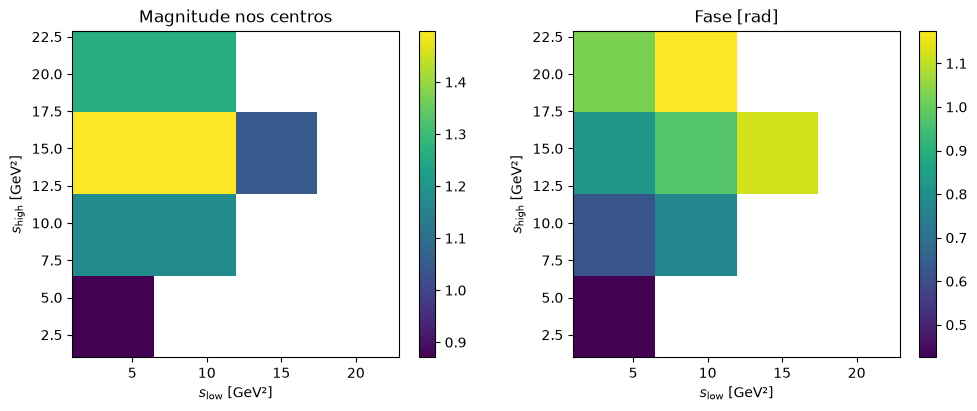

In [3]:
xx, yy = np.meshgrid(centers, centers, indexing="ij")
u, v = (xx - smin) / (smax - smin), (yy - smin) / (smax - smin)
node_magnitudes = 0.8 + 0.8 * np.exp(-((u - 0.25)**2 + (v - 0.65)**2) / 0.12)
node_phases = 0.25 + 0.6 * u + 0.8 * v
node_magnitudes = np.where(active, node_magnitudes, 0.0)
node_phases = np.where(active, node_phases, 0.0)


def make_field(interpolation="linear", node_values=None):
    magnitudes = node_magnitudes.astype(object).copy()
    phases = node_phases.astype(object).copy()
    if node_values is not None:
        magnitudes[fit_cell], phases[fit_cell] = node_values
    return QMI2D(
        s12_edges=edges, s13_edges=edges,
        magnitudes=tuple(tuple(row) for row in magnitudes),
        phases=tuple(tuple(row) for row in phases),
        interpolation=interpolation, folded=True, active_mask=mask,
    )


field = make_field()
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, values, title in zip(
    axes, (node_magnitudes, node_phases), ("Magnitude nos centros", "Fase [rad]")
):
    mesh = ax.pcolormesh(
        edges, edges, np.ma.array(values, mask=~active).T, shading="flat",
    )
    ax.set(xlabel=r"$s_\mathrm{low}$ [GeV²]", ylabel=r"$s_\mathrm{high}$ [GeV²]",
           title=title, aspect="equal")
    fig.colorbar(mesh, ax=ax)
plt.show()

## 3. Comparar `none`, `linear` e `cubic`

- `none`: constante em cada bin; células inativas retornam zero.
- `linear`: interpolação bilinear de magnitude e fase entre os centros.
- `cubic`: interpolação bicúbica local; pode produzir *overshoot*, inclusive magnitudes negativas.

Nas interpolações suaves, células inativas são preenchidas pelo valor da célula
ativa mais próxima como suporte auxiliar. Próximo às bordas externas, as
coordenadas são limitadas ao intervalo dos centros. A máscara **não é um veto
cinemático ponto a ponto**: avalie a distribuição física em eventos de fase espacial.

none: menor magnitude amostrada = 0.8706
linear: menor magnitude amostrada = 0.8706
cubic: menor magnitude amostrada = 0.8706


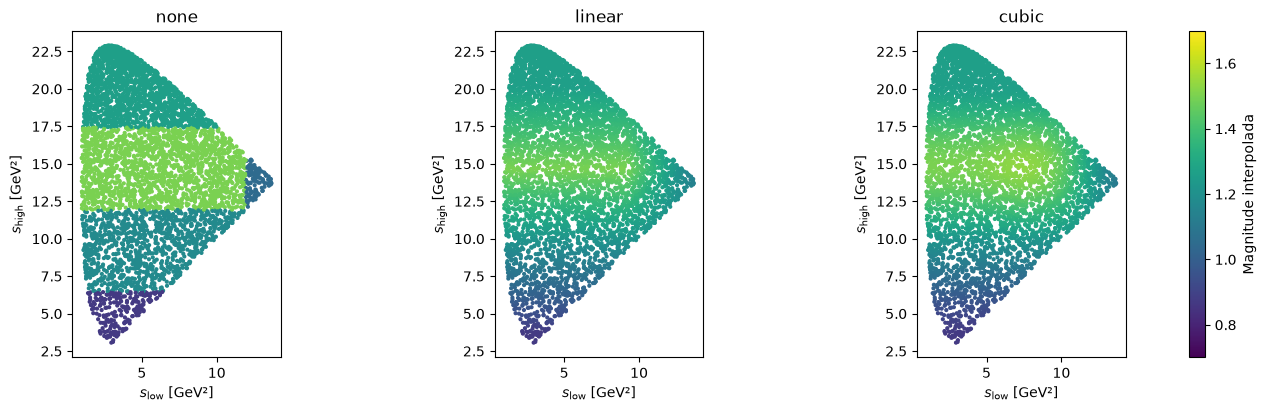

Centros e simetria verificados.


In [4]:
# Usamos uma amostra física apenas para visualizar o campo.
preview_model = DecayModel(
    channel, [DalitzAmplitude("qmi2d", field, RealImag(1.0, 0.0))],
    normalization_resolution=30,
)
probe = preview_model.generate_phase_space(5000, seed=SEED, include_momenta=False)
probe_data = probe.as_dict()
low = np.minimum(probe.s12, probe.s13)
high = np.maximum(probe.s12, probe.s13)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, mode in zip(axes, ("none", "linear", "cubic")):
    candidate = make_field(mode)
    magnitude, phase = candidate.interpolated_magnitude_phase(probe_data)
    scatter = ax.scatter(low, high, c=np.asarray(magnitude), s=4,
                         vmin=0.7, vmax=1.7, rasterized=True)
    ax.set(title=mode, xlabel=r"$s_\mathrm{low}$ [GeV²]",
           ylabel=r"$s_\mathrm{high}$ [GeV²]", aspect="equal")
    print(f"{mode}: menor magnitude amostrada = {float(jnp.min(magnitude)):.4f}")
fig.colorbar(scatter, ax=axes, label="Magnitude interpolada")
plt.show()

# Os centros ativos e a simetria devem ser reproduzidos em todos os modos.
center_data = {"s12": jnp.asarray(xx[active]), "s13": jnp.asarray(yy[active])}
swapped = {"s12": probe.s13, "s13": probe.s12}
for mode in ("none", "linear", "cubic"):
    candidate = make_field(mode)
    a, phi = candidate.interpolated_magnitude_phase(center_data)
    np.testing.assert_allclose(a, node_magnitudes[active], atol=1e-11)
    np.testing.assert_allclose(phi, node_phases[active], atol=1e-11)
    np.testing.assert_allclose(candidate(probe_data), candidate(swapped), atol=1e-11)
print("Centros e simetria verificados.")

## 4. Modelo coerente com uma célula livre

Para um ajuste curto e identificável, liberamos apenas a magnitude e a fase de
uma célula interior. As demais células e os coeficientes ficam fixos.
Todo nó livre usa `Parameter.dynamics(..., owner="qmi2d")`, com `owner` igual
ao nome do `DalitzAmplitude`, para que o cache atualize a dinâmica durante o ajuste.

Adicionamos uma amplitude não ressonante fixa como referência de interferência.
Um campo isolado tem intensidade $|A|^2=a^2$: suas fases não são observáveis
nem mesmo com interpolação de magnitude e fase. Não seria válido ajustar essas
fases em um modelo contendo somente esse campo.

Usamos `normalize_components=False` para manter a escala dos valores brutos em
relação à referência fixa. O `DecayModel` ainda calcula a normalização total,
incluindo interferência. A integração permanece no plano completo, apesar de
`folded=True` no campo.

In [5]:
fit_cell = (0, 2)
assert active[fit_cell]
truth = {
    "qmi2d.a02": float(node_magnitudes[fit_cell]),
    "qmi2d.phi02": float(node_phases[fit_cell]),
}
start = {"qmi2d.a02": 1.05, "qmi2d.phi02": 0.45}
a02 = Parameter.dynamics(
    "qmi2d.a02", start["qmi2d.a02"], owner="qmi2d",
    bounds=(0.2, 2.5), step=0.03,
)
phi02 = Parameter.dynamics(
    "qmi2d.phi02", start["qmi2d.phi02"], owner="qmi2d",
    bounds=(0.0, 2.0), step=0.03,
)
fit_field = make_field(node_values=(a02, phi02))
model = DecayModel(
    channel,
    [DalitzAmplitude("qmi2d", fit_field, RealImag(1.0, 0.0)),
     NonResonant(RealImag(0.65, -0.35), name="reference")],
    normalize_components=False,
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=NORMALIZATION_RESOLUTION,
)
assert {p.name for p in model.parameters if not p.fixed} == set(truth)
print("Parâmetros livres:", list(truth))
print("Verdade:", truth)

Parâmetros livres: ['qmi2d.a02', 'qmi2d.phi02']
Verdade: {'qmi2d.a02': 1.4986815513794882, 'qmi2d.phi02': 0.8250000000000002}


## 5. Gerar e ajustar o toy

A verdade usada na geração é separada do ponto inicial do ajuste. Os eventos
gerados são não ponderados; eles não substituem a amostra de integração.
A resolução da geração por CDF e a resolução da normalização são controles distintos.

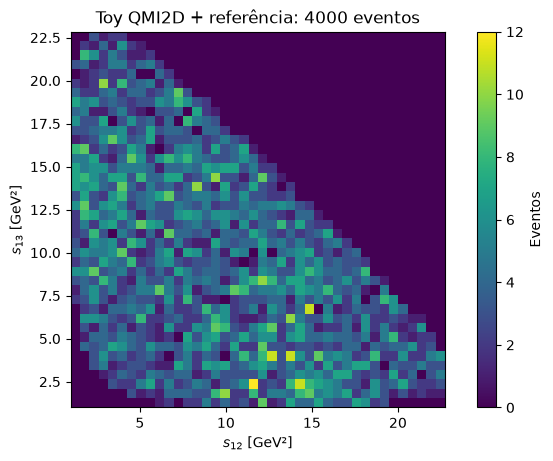

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.269e+04                  │         Nfcn = 60, Ngrad = 7         │
│ EDM = 9.25e-11 (Goal: 1e-07)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘


In [6]:
data = generate_toy(
    model, N_EVENTS, parameters=truth, seed=SEED,
    method="inverse-transform", inverse_resolution=INVERSE_RESOLUTION,
    include_momenta=False,
)
assert data.size == N_EVENTS
np.testing.assert_allclose(data.weights, 1.0)
fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
hist = ax.hist2d(np.asarray(data.s12), np.asarray(data.s13), bins=40)
ax.set(xlabel=r"$s_{12}$ [GeV²]", ylabel=r"$s_{13}$ [GeV²]",
       title=f"Toy QMI2D + referência: {data.size} eventos", aspect="equal")
fig.colorbar(hist[3], ax=ax, label="Eventos")
plt.show()

session = FitSession(model, data)
result = session.fit(start, simplex=False, ncall=5000, strategy=1)
fit_values = {name: float(result.values[name]) for name in result.parameters}
print(result.fmin)

## 6. Diagnósticos e recuperação dos parâmetros

Inspecione validade, EDM, covariância e limites antes de interpretar os erros.
Uma diferença entre verdade e ajuste é esperada por flutuação estatística.
Um toy não demonstra ausência de viés; isso requer um conjunto de toys,
estudos de resolução e diferentes pontos iniciais.

NLL: {'início': 22707.582340707668, 'verdade': 22693.999441265205, 'ajuste': 22693.808575136973}
Covariância precisa: True
Parâmetros nos limites: False
qmi2d.a02: verdade=1.4987, ajuste=1.6498 ± 0.3318, pull=0.46
qmi2d.phi02: verdade=0.8250, ajuste=1.0143 ± 0.4572, pull=0.41


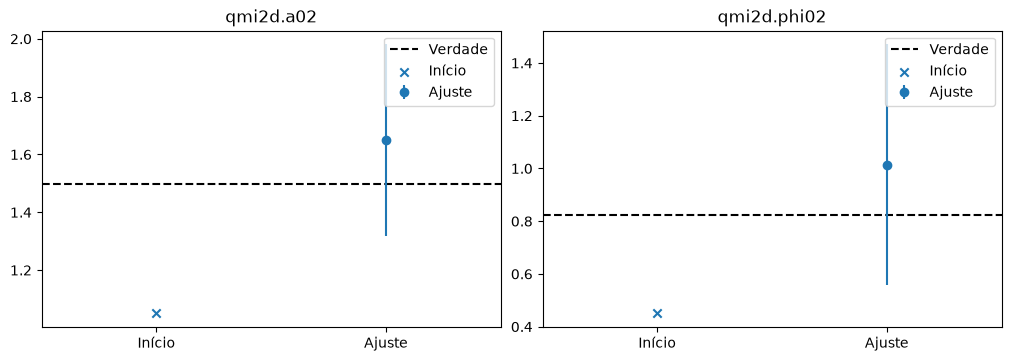

In [7]:
nll = {label: float(session.objective(values))
       for label, values in (("início", start), ("verdade", truth), ("ajuste", fit_values))}
print("NLL:", nll)
print("Covariância precisa:", result.fmin.has_accurate_covar)
print("Parâmetros nos limites:", result.fmin.has_parameters_at_limit)
assert result.valid, "Inspecione o diagnóstico do minimizador."
assert nll["ajuste"] <= nll["início"] + 1e-5
assert nll["ajuste"] <= nll["verdade"] + 1e-5

for name in truth:
    error = float(result.errors[name])
    assert np.isfinite(error) and error > 0
    pull = (fit_values[name] - truth[name]) / error
    print(f"{name}: verdade={truth[name]:.4f}, ajuste={fit_values[name]:.4f} "
          f"± {error:.4f}, pull={pull:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for ax, name in zip(axes, truth):
    ax.axhline(truth[name], color="black", linestyle="--", label="Verdade")
    ax.scatter([0], [start[name]], marker="x", label="Início")
    ax.errorbar([1], [fit_values[name]], yerr=[result.errors[name]], fmt="o", label="Ajuste")
    ax.set(xticks=[0, 1], xticklabels=["Início", "Ajuste"], title=name, xlim=(-0.5, 1.5))
    ax.legend()
plt.show()

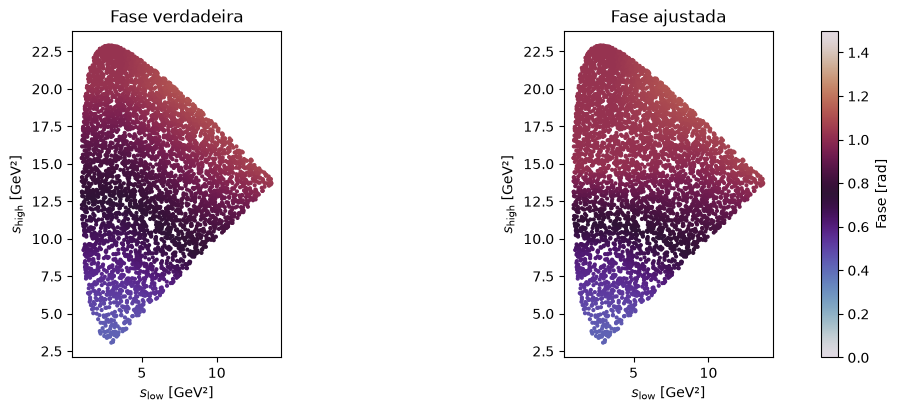

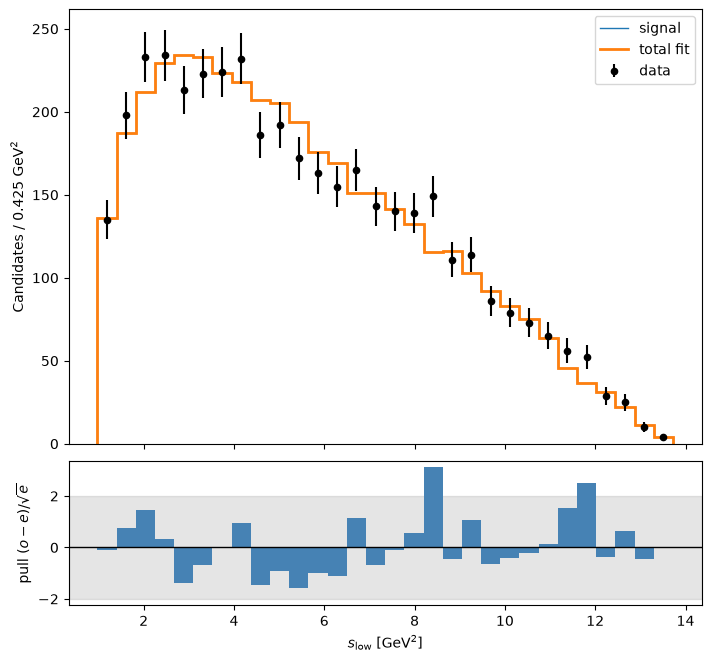

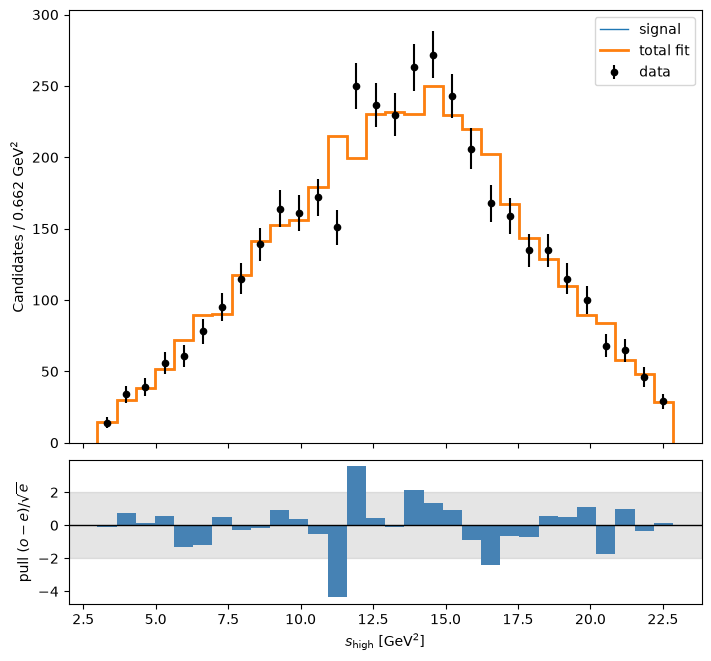

In [8]:
# Reconstruímos um campo numérico para visualizar os valores ajustados.
# A resolução de Parameter acontece pelo DecayModel, não por field(data, values).
fitted_field = make_field(node_values=(fit_values["qmi2d.a02"], fit_values["qmi2d.phi02"]))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, candidate, title in zip(axes, (field, fitted_field), ("Fase verdadeira", "Fase ajustada")):
    _, phase = candidate.interpolated_magnitude_phase(probe_data)
    scatter = ax.scatter(low, high, c=np.asarray(phase), s=4,
                         vmin=0.0, vmax=1.5, cmap="twilight", rasterized=True)
    ax.set(title=title, xlabel=r"$s_\mathrm{low}$ [GeV²]",
           ylabel=r"$s_\mathrm{high}$ [GeV²]", aspect="equal")
fig.colorbar(scatter, ax=axes, label="Fase [rad]")
plt.show()

for side in ("low", "high"):
    session.plot_projection(
        result, "s12", bins=30, projection_size=15000,
        folded=True, partner_variable="s13", fold_side=side,
        show_pulls=True,
    )
    plt.show()

## 7. Próximos exercícios

1. Aumente `NORMALIZATION_RESOLUTION` e `INVERSE_RESOLUTION` separadamente e
   compare os parâmetros recuperados com seus erros.
2. Repita com outras sementes e pontos iniciais; examine a distribuição dos pulls.
3. Troque a interpolação tanto na geração quanto no ajuste. Para `none`,
   verifique especialmente a convergência da integração nas descontinuidades.
4. Libere outras células ativas gradualmente, verificando ocupação, correlações
   e covariância. Fixe referências de escala e fase ao ampliar o modelo; um campo
   inteiramente livre pode introduzir direções degeneradas mesmo com interferência.
5. Para um canal sem a simetria usada aqui, construa bordas próprias para cada
   eixo e use `folded=False` tanto na máscara quanto no campo.

Referências locais: [QMI2D](../../docs/lineshapes.md#qmi2d-dalitz-amplitude),
[ajustes](../../docs/fitting.md), [normalização](tutorial_03_normalization.ipynb)
e [guia de tutoriais](TUTORIALS.md).